# Sudan Climate EDA
NASA POWER MERRA-2 Daily Data — Khartoum (2015–2026)

## 1. Data Loading & Date Parsing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/sudan.csv')
df['Country'] = 'Sudan'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
print(df.shape)
df.head()

(4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


## 2. Summary Statistics & Missing Value Report

In [2]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


In [3]:
print('Duplicate rows:', df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


**Duplicates:** Any duplicate rows found are dropped. Duplicates in NASA POWER data are rare but can occur due to extraction errors.

In [4]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


**Interpretation of Summary Statistics:**
- T2M is the highest among all five countries, averaging ~30°C, reflecting Khartoum's hot desert climate.
- T2M_RANGE is large, indicating extreme diurnal temperature swings typical of arid environments.
- PRECTOTCORR is very low on average with most days recording 0mm, consistent with Sudan's desert climate.
- RH2M is the lowest among all countries, confirming extremely dry conditions.

In [5]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_report[missing_report['Missing %'] > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


**Missing Values:**
Columns with >5% missing values are flagged. In arid regions like Sudan, some parameters may have more missing values due to limited ground-truth data for satellite model calibration.

## 3. Outlier Detection & Basic Cleaning

In [6]:
climate_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = df[climate_cols].apply(lambda col: np.abs(stats.zscore(col.dropna())))
outlier_counts = (z_scores > 3).sum()
print('Outlier counts per column (|Z| > 3):')
print(outlier_counts)

Outlier counts per column (|Z| > 3):
T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


**Outlier Decision:**
Outliers are retained. Sudan's extreme heat events and rare but intense rainfall episodes are climatically significant and must be preserved for the extreme event analysis in Task 3.

In [7]:
df[climate_cols] = df[climate_cols].ffill()
threshold = len(df.columns) * 0.7
df.dropna(thresh=int(threshold), inplace=True)
print('Shape after cleaning:', df.shape)

Shape after cleaning: (4108, 15)


In [8]:
import os
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/sudan_clean.csv', index=False)
print('Exported to data/sudan_clean.csv')

Exported to data/sudan_clean.csv


## 4. Time Series Analysis

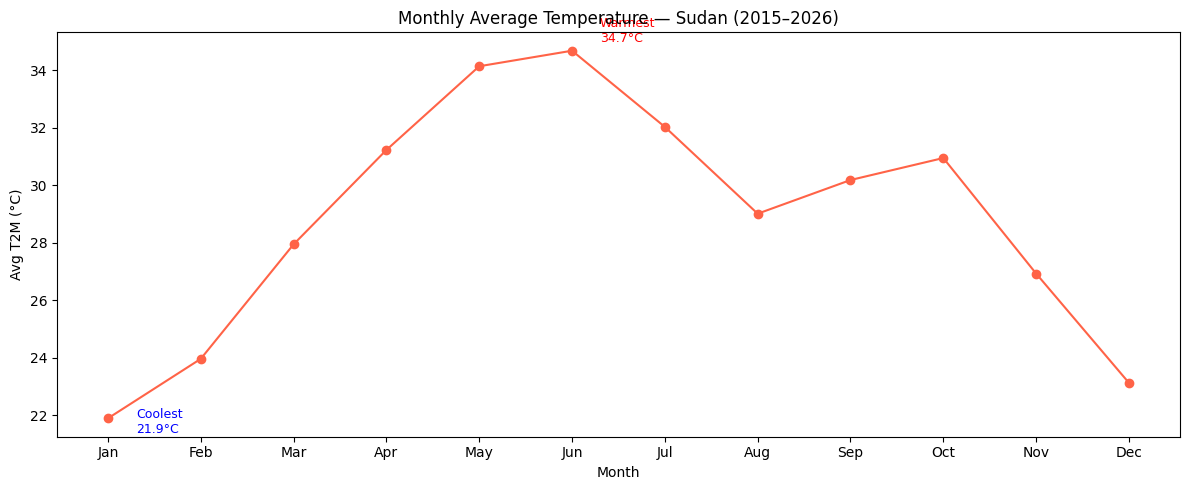

In [9]:
monthly_temp = df.groupby('Month')['T2M'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato')

warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
ax.annotate(f'Warmest\n{monthly_temp[warmest]:.1f}°C', xy=(warmest, monthly_temp[warmest]),
            xytext=(warmest + 0.3, monthly_temp[warmest] + 0.3), fontsize=9, color='red')
ax.annotate(f'Coolest\n{monthly_temp[coolest]:.1f}°C', xy=(coolest, monthly_temp[coolest]),
            xytext=(coolest + 0.3, monthly_temp[coolest] - 0.5), fontsize=9, color='blue')

ax.set_title('Monthly Average Temperature — Sudan (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg T2M (°C)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

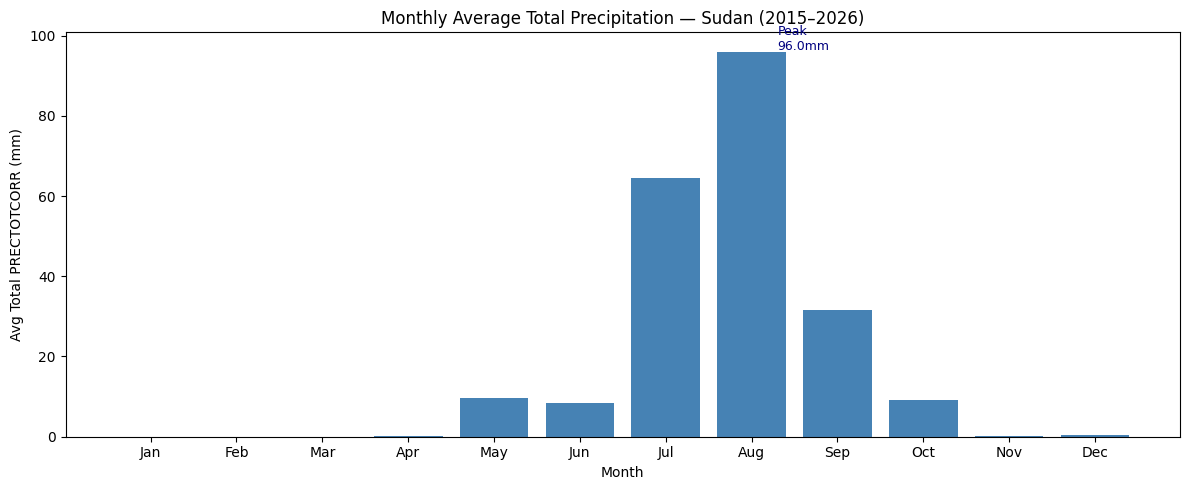

In [10]:
monthly_rain = df.groupby('Month')['PRECTOTCORR'].sum() / df['YEAR'].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_rain.index, monthly_rain.values, color='steelblue')

peak = monthly_rain.idxmax()
ax.annotate(f'Peak\n{monthly_rain[peak]:.1f}mm', xy=(peak, monthly_rain[peak]),
            xytext=(peak + 0.3, monthly_rain[peak] + 0.5), fontsize=9, color='navy')

ax.set_title('Monthly Average Total Precipitation — Sudan (2015–2026)')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Total PRECTOTCORR (mm)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

**Time Series Observations:**
- Sudan shows the most extreme temperature seasonality, peaking around May–June before the brief rainy season cools things slightly.
- Rainfall is concentrated in July–August only, with near-zero precipitation for the rest of the year.
- This pattern reflects a Sahel/desert climate with a very short and unreliable wet season — a major climate vulnerability.

## 5. Correlation & Relationship Analysis

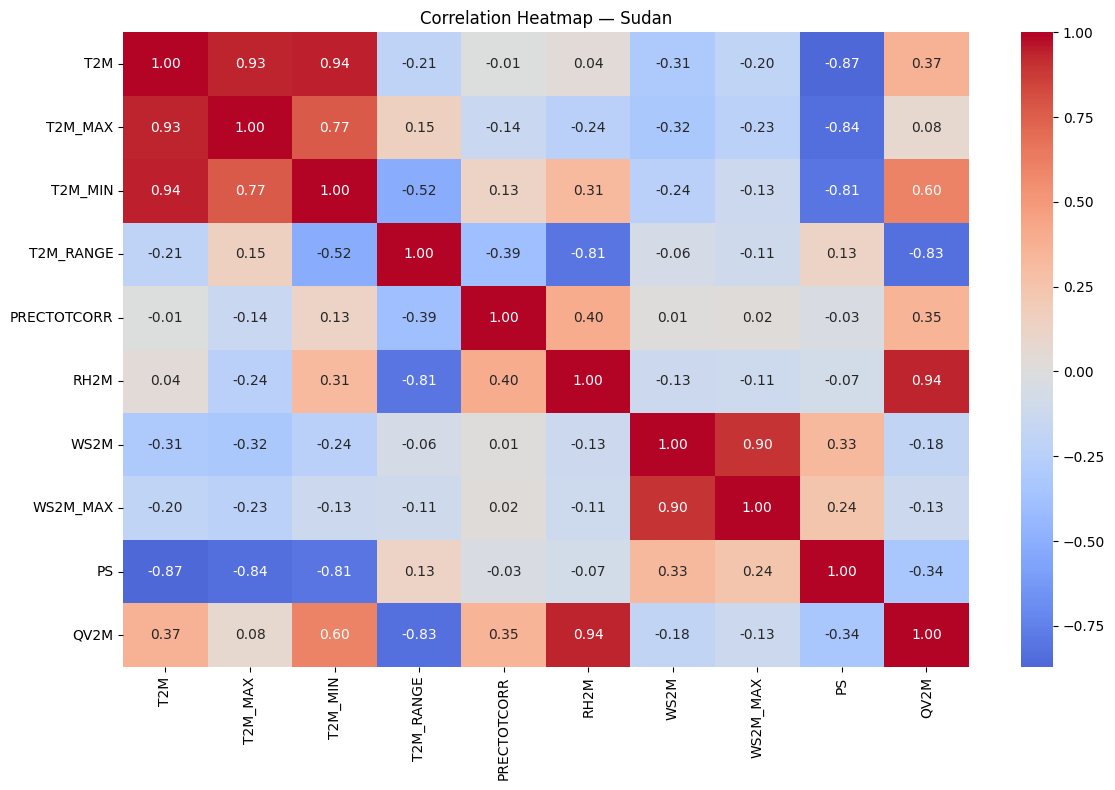

In [11]:
numeric_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Sudan')
plt.tight_layout()
plt.show()

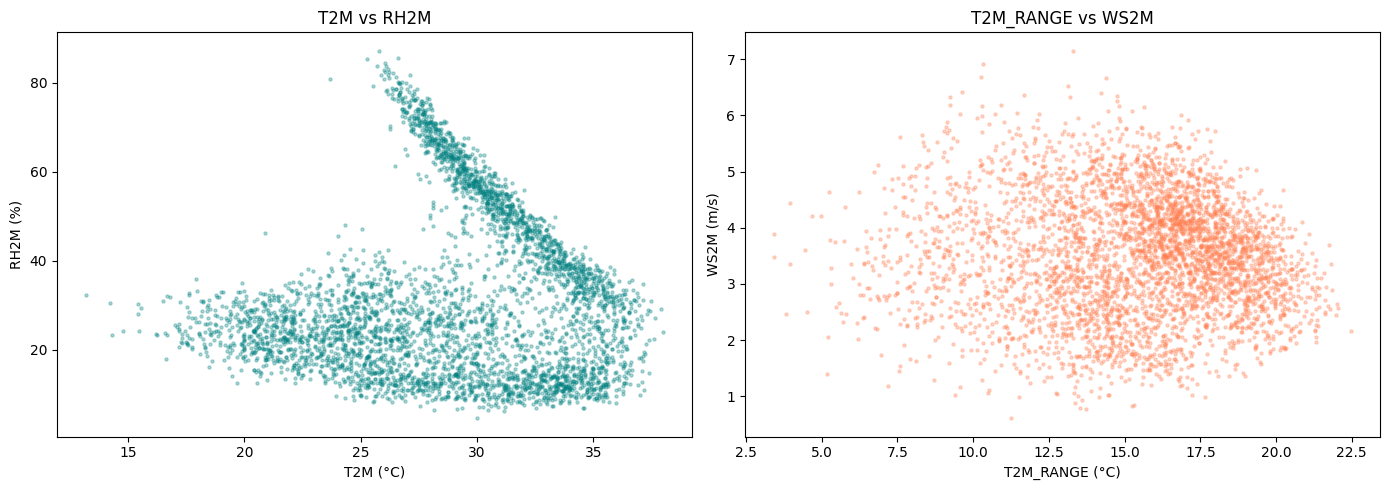

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal', s=5)
ax1.set_title('T2M vs RH2M')
ax1.set_xlabel('T2M (°C)')
ax1.set_ylabel('RH2M (%)')

ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral', s=5)
ax2.set_title('T2M_RANGE vs WS2M')
ax2.set_xlabel('T2M_RANGE (°C)')
ax2.set_ylabel('WS2M (m/s)')

plt.tight_layout()
plt.show()

**Three Strongest Correlations:**
1. **T2M & T2M_MAX / T2M_MIN** — Very strong positive correlation as expected.
2. **T2M & QV2M** — Strong positive correlation; desert air holds little moisture but spikes during the brief rainy season.
3. **T2M & RH2M** — Strong negative correlation in arid climates; as temperature rises, relative humidity drops sharply.

## 6. Distribution Analysis

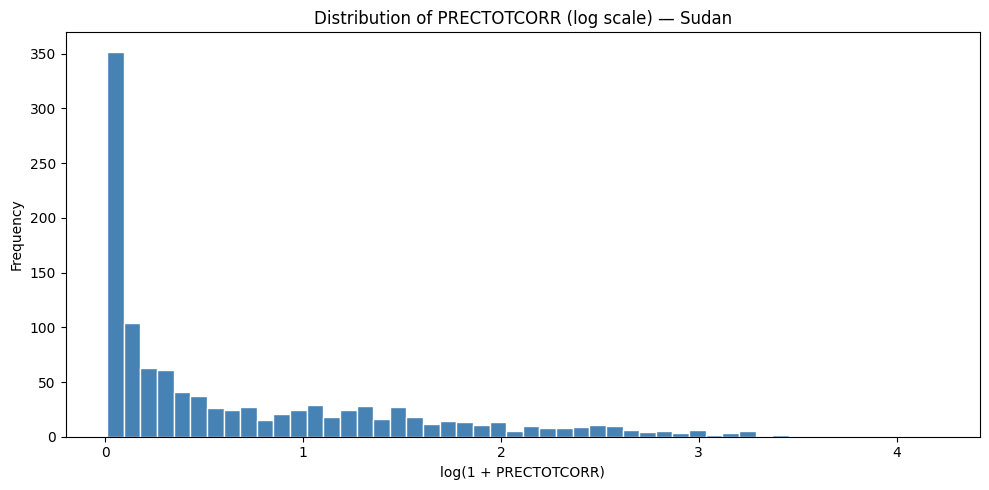

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
rain_nonzero = df['PRECTOTCORR'][df['PRECTOTCORR'] > 0]
ax.hist(np.log1p(rain_nonzero), bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of PRECTOTCORR (log scale) — Sudan')
ax.set_xlabel('log(1 + PRECTOTCORR)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

**Precipitation Distribution:**
Sudan has the most extreme skew — the vast majority of days record 0mm. Even after log transformation, the distribution remains skewed, reflecting the desert climate where rainfall is rare and highly concentrated in a few intense events.

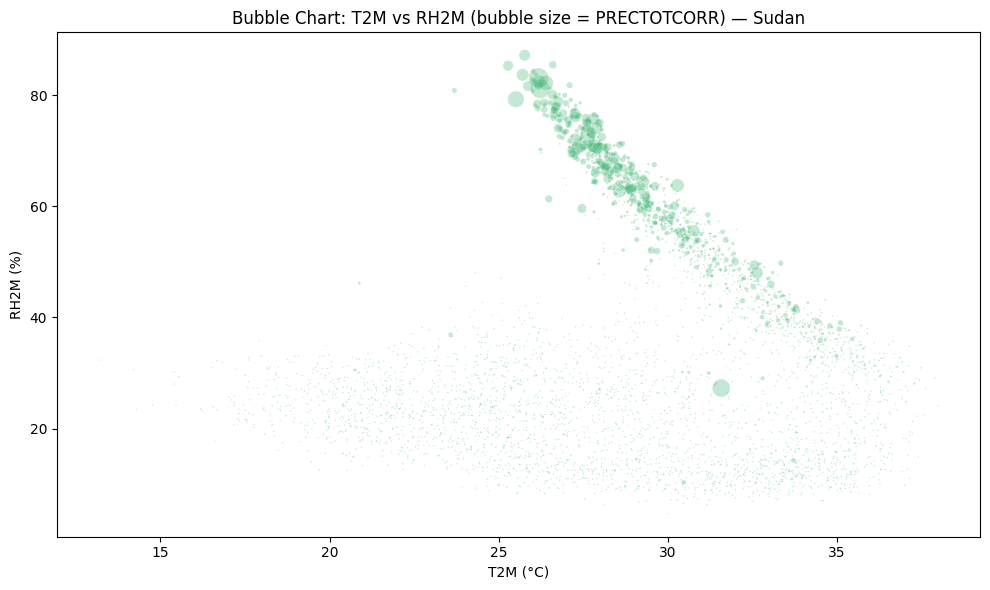

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR'] * 3 + 1,
            alpha=0.3, color='mediumseagreen', edgecolors='none')
plt.title('Bubble Chart: T2M vs RH2M (bubble size = PRECTOTCORR) — Sudan')
plt.xlabel('T2M (°C)')
plt.ylabel('RH2M (%)')
plt.tight_layout()
plt.show()